In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_path = Path("datasets")

### What is stationary
* constant mean (no trend vs time)
* constant variance (no variance change vs time)
* constant autocorrelation (how data point values depend on their neighbors), so we can use AR

### Data exploration for stationary
* read time series data and define timestamp index
* plot time series data using pandas' wrapper plot() function
* the candy data shows parent trends and therefore is not stationary

In [3]:
candy_path = data_path / "candy_production.csv"
earthquake_path = data_path / "earthquakes.csv"
amazon_path = data_path / "amazon_close.csv"

candy = pd.read_csv(candy_path, index_col='date', parse_dates=['date'])
earthquake = pd.read_csv(earthquake_path, index_col='date', parse_dates=['date'])
amazon = pd.read_csv(amazon_path, index_col='date', parse_dates=['date'])

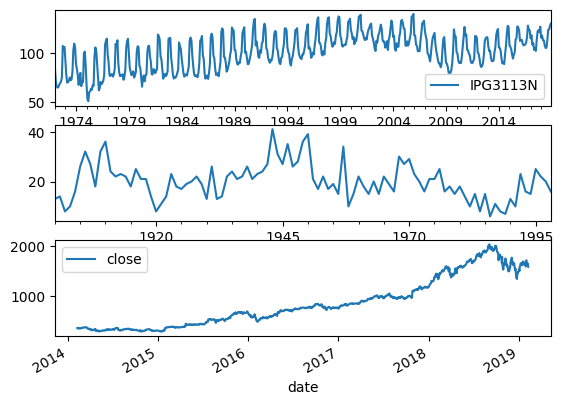

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
candy.plot(ax=ax1)
earthquake['earthquakes_per_year'].plot(ax=ax2)
amazon.plot(ax=ax3)
plt.show()

### Augmented dicky-fuller test for stationary
* null hypothesis is that the data is non-stationary with coefficient of y(t-1) = 1 (e.g. random walk)
* alternative hypothesis: coefficient < 1 (stationary)
* we need to find a small p-value (e.g. < 0.05)
* output contains:
  + result\[0]: test statistic value
  + result\[1]: p-value
  + result\[3]: critical values for different alpha value (e.g. 0.1, 0.05)
* candy data is not stationary with a p-value of 0.39
* earthquake data is stationary with a small p-value of 0.02 < 0.05 

#### Augmented dicky-fuller tests for candy data
* the data is not stationary with a large p-value of 0.39
* we can see the trend in the data

In [5]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(candy)

# print test statistics
print(result[0])

# print p-value
print(result[1])

# print critical values
print(result[4])

-1.7760153075016243
0.39243275007139333
{'1%': -3.4423174665535385, '5%': -2.866818952732754, '10%': -2.569581505602171}


#### Augmented dicky-fuller tests for earthquakes data
* the data is stationary with a small p-value of 0.02
* we can observe that the data don't have trends

In [6]:
result = adfuller(earthquake['earthquakes_per_year'])

# print test statistics
print(result[0])

# print p-value
print(result[1])

# print critical values
print(result[4])

-3.183192251191782
0.02097842525600371
{'1%': -3.5003788874873405, '5%': -2.8921519665075235, '10%': -2.5830997960069446}


In [7]:
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 99 entries, 1900-01-01 to 1998-01-01
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  99 non-null     int64  
 1   earthquakes_per_year  99 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 2.3 KB


In [8]:
earthquake.head()

,Year,earthquakes_per_year
date,,
1900-01-01,1900,13.0
1901-01-01,1901,14.0
1902-01-01,1902,8.0
1903-01-01,1903,10.0
1904-01-01,1904,16.0


### Making time series stationary
* use the first or second order differencing
  + apply first order differencing on earthquake data makes it stationary
* use data transformation, such as logrithm (np.log), square root (np.sqrt), and proportional change df.shift(1)/df
  + we can make amazon stock price stationary by both first order differencing and log transformation
  + log transformation results in more constant data variance and much smaller test statistics compared to differencing
  + we select log transformation since the resulting data is stationary, not only in terms of trend

#### Make earthquake data stationary by differencing

1.7445517772027128e-19


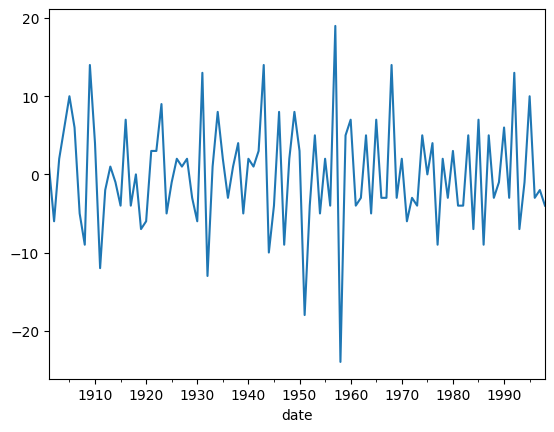

In [9]:
earthquake_diff = earthquake['earthquakes_per_year'].diff().dropna()
earthquake_diff.plot()
result = adfuller(earthquake_diff)
print(result[1])

#### Process amazon data by differencing

(-7.203579488811309, 2.3312717254863136e-10)


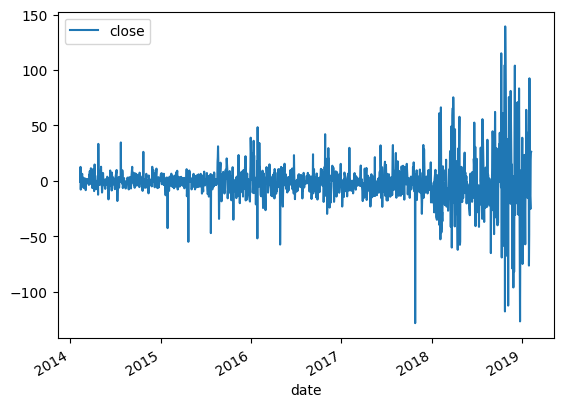

In [10]:
amazon_diff = amazon.diff().dropna()
amazon_diff.plot()
result = adfuller(amazon_diff)
print(result[:2])

#### Process amazon data by log difference
* `np.log(amazon/amazon.shift(1))`

(-34.915748536059674, 0.0)


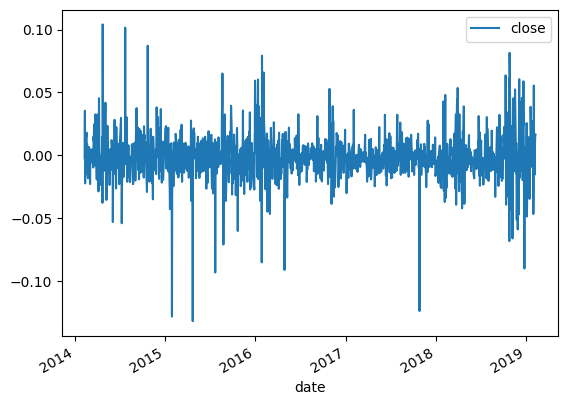

In [11]:
amazon_log = np.log(amazon / amazon.shift(1)).dropna()
amazon_log.plot()
result = adfuller(amazon_log)
print(result[:2])

### AR, MA and ARMA models
* AR (Autoregressive) model relates results at timestamp t with results at previous timestamps (lags such as t-1, t-2 etc.)
* MA (moving average) mode relates results at timestamp t with shock/residual at previous timestamps (lags such as t-1, t-2 etc.)
* ARMA model includes both AR and MA as ARMA = RA + MA, y(t) = a * y(t-1) + m * e(t-1) + e(t)
* we can simulate ARMA data using arma_generate_sample function, with ar_coefs = \[1, -0.5\], ma_coefs = \[1, 0.2\]
  + ar_coefs needs to use the negative of the true ar coefficient, ma keeps the same
  + you need to define the zero lag coefficient as 1. for AR(0) and MA(0), we set ar_coefs=\[1\] and ma_coefs=\[1\]
  ```python
  from statsmodels.tsa.arima_process import arma_generate_sample
  ar_coefs = [1, -0.5]
  ma_coefs = [1, 0.2]
  y = arma_generate_sample(ar_coefs, ma_coefs, nsample=100, scale=0.3)
  ```

In [12]:
from statsmodels.tsa.arima_process import arma_generate_sample

ar_coefs = [1, -0.5]
ma_coefs = [1, 0.7]

# generate data for y(t) = 0.5 * y(t-1) + 0.2 * e(t-1) + e(t), with e has a standard deviation of 0.5 with normal distribution
# sigma(e) = 0.5 * 0.5 = 0.25
y = arma_generate_sample(ar_coefs, ma_coefs, nsample=100, scale=0.3)
y_df = pd.DataFrame({'date': pd.date_range(start='2021-01-01', periods=len(y)), 'y': y})

y_df = y_df.set_index("date", drop=True).asfreq('D')
y_df.head()

,y
date,
2021-01-01,-0.414971
2021-01-02,-0.941596
2021-01-03,-0.932896
2021-01-04,-0.608755
2021-01-05,-0.467690


In [13]:
y_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2021-01-01 to 2021-04-10
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       100 non-null    float64
dtypes: float64(1)
memory usage: 1.6 KB


<Axes: xlabel='date'>

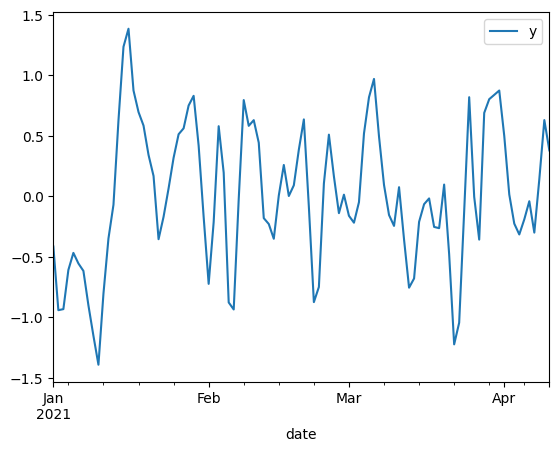

In [14]:
y_df.plot()

### Fit ARMA model using ARIMA model from statsmodels
* fit simulated data generated by arma_generate_sample
  + we get a = 0.51 and m = 0.64 vs. 0.5 and 0.7, respectively
* fit earthquake data. We know it is stationary
  + the fitted results are not good as shown by p-values of coefficients and prob(JB) close to 0.05, meaning residuals may not be normal

#### Fit simulated data

In [15]:
from statsmodels.tsa.arima.model import ARIMA

# instantiate model object
model = ARIMA(y_df, order=(1,0,1))

# fit model
results = model.fit()

# see results
print(results.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -29.649
Date:                Thu, 05 Mar 2026   AIC                             67.299
Time:                        19:56:47   BIC                             77.720
Sample:                    01-01-2021   HQIC                            71.516
                         - 04-10-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0074      0.116      0.064      0.949      -0.219       0.234
ar.L1          0.5026      0.092      5.492      0.000       0.323       0.682
ma.L1          0.7719      0.074     10.478      0.0

#### Fit earthquake data

In [16]:
model = ARIMA(earthquake['earthquakes_per_year'], order=(3,0,1))

results = model.fit()
print(results.summary())

                                SARIMAX Results                                 
Dep. Variable:     earthquakes_per_year   No. Observations:                   99
Model:                   ARIMA(3, 0, 1)   Log Likelihood                -315.673
Date:                  Thu, 05 Mar 2026   AIC                            643.345
Time:                          19:56:47   BIC                            658.916
Sample:                      01-01-1900   HQIC                           649.645
                           - 01-01-1998                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.6453      2.233      8.798      0.000      15.269      24.022
ar.L1          0.5795      0.645      0.899      0.369      -0.684       1.843
ar.L2          0.0251      0.308    

C:\Users\huang\anaconda3\envs\farm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\huang\anaconda3\envs\farm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\huang\anaconda3\envs\farm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


#### Fit amazon data

In [17]:
amazon = amazon.sort_index()
amazon = amazon.loc['2018':, :]

In [18]:
# use first order differencing and AR(2) and MA(2)
arma = ARIMA(amazon.asfreq('D'), order=(2, 1, 2))
arma_results = arma.fit()
print(arma_results.summary())


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  403
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1396.232
Date:                Thu, 05 Mar 2026   AIC                           2802.463
Time:                        19:56:47   BIC                           2822.445
Sample:                    01-02-2018   HQIC                          2810.375
                         - 02-08-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3259      0.292     -1.117      0.264      -0.898       0.246
ar.L2         -0.5307      0.270     -1.965      0.049      -1.060      -0.001
ma.L1          0.1900      0.296      0.642      0.5

In [19]:
amazon.head()

,close
date,
2018-01-02,1189.01
2018-01-03,1204.20
2018-01-04,1209.59
2018-01-05,1229.14
2018-01-08,1246.87


### Create prediction from ARIMA model
#### One step forecast
* one_step_forecast = fitted_model.get_predictions(start=-30) to predict the last 30 steps
* mean_forecast = one_step_forecast.predicted_mean
* confidence_intervals = one_step_forecast.conf_int()
  + lower_limits
  + upper_limits

In [20]:
one_step_forecast = arma_results.get_prediction(start=-30)
mean_forecast = one_step_forecast.predicted_mean
confidence_intervals = one_step_forecast.conf_int()

lower_limits = confidence_intervals.loc[:, 'lower close']
upper_limits = confidence_intervals.loc[:, 'upper close']

print(mean_forecast)

date
2019-01-10    1656.073243
2019-01-11    1659.770000
2019-01-12    1643.790218
2019-01-13    1643.585323
2019-01-14    1641.937659
2019-01-15    1619.338426
2019-01-16    1668.161416
2019-01-17    1674.061278
2019-01-18    1694.873580
2019-01-19    1697.882823
2019-01-20    1696.268190
2019-01-21    1695.901206
2019-01-22    1696.877762
2019-01-23    1634.650014
2019-01-24    1639.826818
2019-01-25    1650.692018
2019-01-26    1667.106621
2019-01-27    1667.624846
2019-01-28    1669.294153
2019-01-29    1638.956289
2019-01-30    1598.884661
2019-01-31    1664.855017
2019-02-01    1699.945488
2019-02-02    1637.660728
2019-02-03    1654.387222
2019-02-04    1642.869593
2019-02-05    1628.758977
2019-02-06    1662.760126
2019-02-07    1640.029142
2019-02-08    1619.161083
Freq: D, Name: predicted_mean, dtype: float64


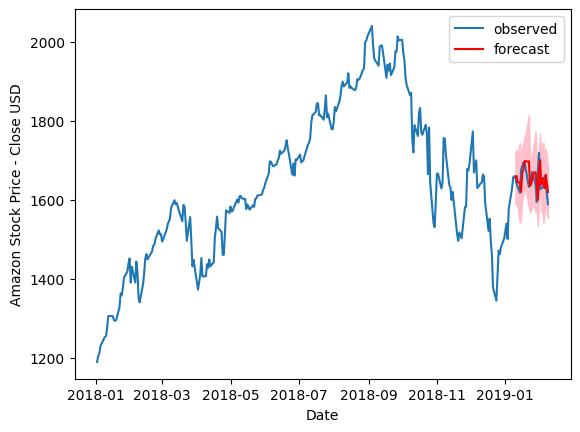

In [21]:
plt.plot(amazon.index, amazon, label='observed')
plt.plot(mean_forecast.index, mean_forecast, color='r', label='forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color='pink')

plt.xlabel('Date')
plt.ylabel('Amazon Stock Price - Close USD')
plt.legend()
plt.show()

#### Dynamic forecast
* dynamic forecast without using the training data
* get predictions and then use training data at these points to evaluate model
* dynamic_forecast = fitted_model.get_predictions(start=-30, dynamic=True) to predict the last 30 steps without using training data at these steps
* mean_forecast = dynamic_forecast.predicted_mean
* confidence_intervals = dynamic_forecast.conf_int()
  + lower_limits
  + upper_limits

In [22]:
dynamic_forecast = arma_results.get_prediction(start=-30)
mean_forecast = dynamic_forecast.predicted_mean
confidence_intervals = dynamic_forecast.conf_int()

lower_limits = confidence_intervals.loc[:, 'lower close']
upper_limits = confidence_intervals.loc[:, 'upper close']

print(mean_forecast)

date
2019-01-10    1656.073243
2019-01-11    1659.770000
2019-01-12    1643.790218
2019-01-13    1643.585323
2019-01-14    1641.937659
2019-01-15    1619.338426
2019-01-16    1668.161416
2019-01-17    1674.061278
2019-01-18    1694.873580
2019-01-19    1697.882823
2019-01-20    1696.268190
2019-01-21    1695.901206
2019-01-22    1696.877762
2019-01-23    1634.650014
2019-01-24    1639.826818
2019-01-25    1650.692018
2019-01-26    1667.106621
2019-01-27    1667.624846
2019-01-28    1669.294153
2019-01-29    1638.956289
2019-01-30    1598.884661
2019-01-31    1664.855017
2019-02-01    1699.945488
2019-02-02    1637.660728
2019-02-03    1654.387222
2019-02-04    1642.869593
2019-02-05    1628.758977
2019-02-06    1662.760126
2019-02-07    1640.029142
2019-02-08    1619.161083
Freq: D, Name: predicted_mean, dtype: float64


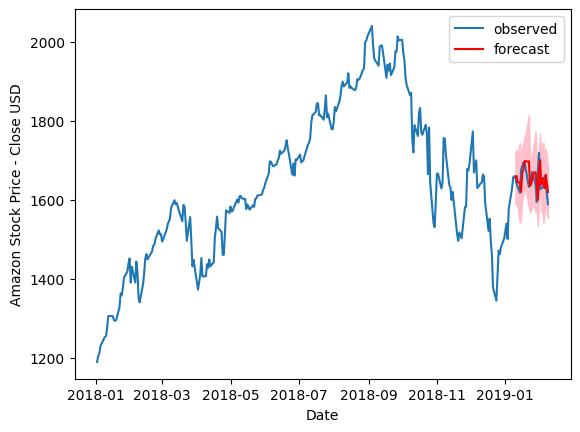

In [23]:
plt.plot(amazon.index, amazon, label='observed')
plt.plot(mean_forecast.index, mean_forecast, color='r', label='forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color='pink')

plt.xlabel('Date')
plt.ylabel('Amazon Stock Price - Close USD')
plt.legend()
plt.show()

#### Manually difference amazon without using ARIMA (x, 1, x)
```Python
amazon_diff = amazon.diff().dropna()
arma = ARIMA(amazon_diff, order=(2, 0, 2))
arma_results = arma.fit()
print(arma_results.summary())
```
* work on amazon.diff() for prediction
* revert back to original dataset by
  ```Python
  # make arma forecast of next 10 differences
  arma_diff_forecast = arma_results.get_forecast(steps=10).predicted_mean

  # intergrate the difference forecast
  arma_int_forecast = np.cumsum(arma_diff_forecast)

  # Make absolute value forecast
  arma_value_forecast = arma_int_forecast + amazon.iloc[-1, 0]

  # print forecast
  print(arma_value_forecast)
```  
  

In [24]:
arma = ARIMA(amazon_diff.asfreq('D'), order = (2, 0, 2))
arma_results = arma.fit()
print(arma_results.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 1824
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -5531.964
Date:                Thu, 05 Mar 2026   AIC                          11075.928
Time:                        19:56:49   BIC                          11108.981
Sample:                    02-10-2014   HQIC                         11088.121
                         - 02-07-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9925      0.496     -2.002      0.045      -1.964      -0.021
ar.L1          0.1008      0.078      1.293      0.196      -0.052       0.254
ar.L2          0.6948      0.064     10.793      0.0

In [25]:
# make arma forecast of next 10 differences
arma_diff_forecast = arma_results.get_forecast(steps=10).predicted_mean

# intergrate the difference forecast
arma_int_forecast = np.cumsum(arma_diff_forecast)

# Make absolute value forecast
arma_value_forecast = arma_int_forecast + amazon.iloc[-1, 0]

# print forecast
print(arma_value_forecast)

2019-02-08    1586.113418
2019-02-09    1582.492003
2019-02-10    1580.460324
2019-02-11    1577.536439
2019-02-12    1575.627142
2019-02-13    1573.200247
2019-02-14    1571.426098
2019-02-15    1569.358142
2019-02-16    1567.714091
2019-02-17    1565.908647
Freq: D, Name: predicted_mean, dtype: float64


### AR and MA diagnosis using ACF(Autocorrelation Function) and PACF(Partial Autocorrelation Function)
* use ACF for MA(q) if ACF cuts off after lag q. ACF tails off for AR(p)
* use PACF for AR(p) if PACF cuts off after lag p. PACF tails off for MA(q)
* for ARMA(p,q), we can't use ACF and PACF to find orders
```Python
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    
    # create figure
    fig, (ax1, ax2) = plt.subplots(2,1, figsize(12,8))
    
    # plot the ACF
    plot_acf(df, lags=10, zero=False, ax=ax1)

    # plot PACF
    plot_pacf(df, lags=10, zero=False, ax=ax2)

    plt.show()
```

#### using ACF and PACF on earthquake data
* ACF tails off and PACF cuts off after lag 1, so its AR(1)

#### Define function to traverse p and q values
* traverse all p and q values and fit models
* save p, q, aic and bic of model
* sort the solutions by aic
* use the lowest aic model with corresponding p and q

In [26]:
earthquake.head()

,Year,earthquakes_per_year
date,,
1900-01-01,1900,13.0
1901-01-01,1901,14.0
1902-01-01,1902,8.0
1903-01-01,1903,10.0
1904-01-01,1904,16.0


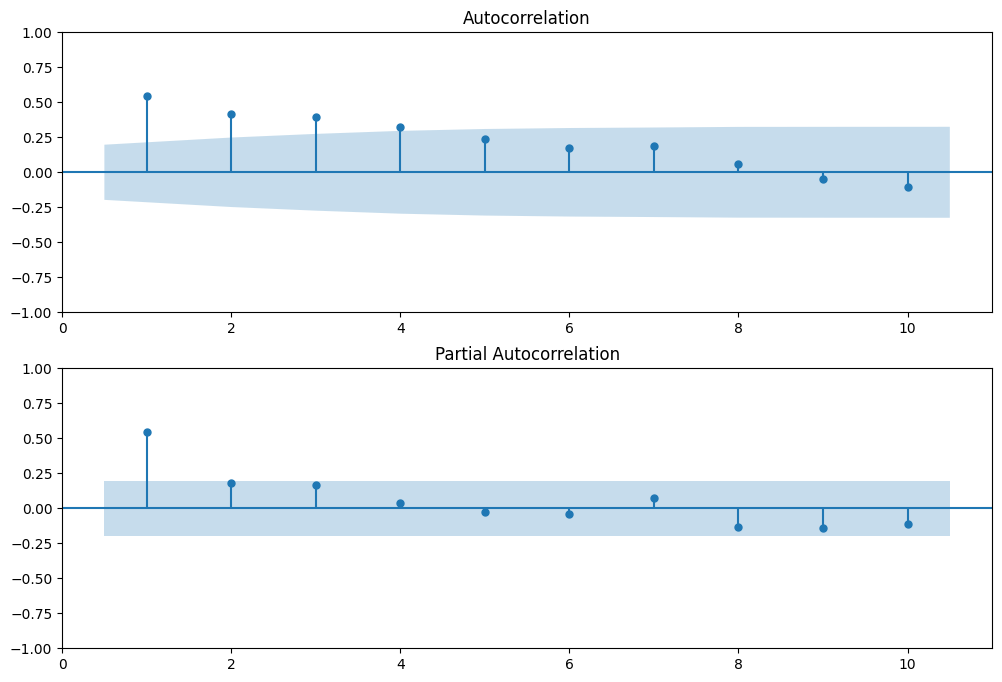

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
earthquake_df = earthquake['earthquakes_per_year']
    
# create figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))

# plot the ACF
plot_acf(earthquake_df, lags=10, zero=False, ax=ax1)

# plot PACF
plot_pacf(earthquake_df, lags=10, zero=False, ax=ax2)

plt.show()

In [28]:
model = ARIMA(earthquake_df.asfreq('YS-JAN'), order=(1,0,0))
results = model.fit()
print(results.summary())

                                SARIMAX Results                                 
Dep. Variable:     earthquakes_per_year   No. Observations:                   99
Model:                   ARIMA(1, 0, 0)   Log Likelihood                -318.984
Date:                  Thu, 05 Mar 2026   AIC                            643.968
Time:                          19:56:50   BIC                            651.753
Sample:                      01-01-1900   HQIC                           647.118
                           - 01-01-1998                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.8906      1.420     14.004      0.000      17.107      22.674
ar.L1          0.5433      0.078      6.930      0.000       0.390       0.697
sigma2        36.6976      4.832    

In [29]:
def fit_ARIMA(input_data: pd.DataFrame, p_range: int, q_range: int, i_value: int=0) -> pd.DataFrame:
    order_aic_bic = []
    
    for p in range(p_range):
        for q in range(q_range):
            try:
                model = ARIMA(input_data, order=(p, i_value, q))
                results = model.fit()
                order_aic_bic.append((p, q, results.aic, results.bic))
            except:
                print(p, q, None, None)

    order_df = pd.DataFrame(order_aic_bic, columns=['p', 'q', 'AIC', 'BIC'])
    order_df = order_df.sort_values(['AIC'])
    return order_df


In [30]:
arima_df = fit_ARIMA(earthquake_df.asfreq('YS-JAN'), 3, 3)

C:\Users\huang\anaconda3\envs\farm\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\huang\anaconda3\envs\farm\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
arima_df

,p,q,AIC,BIC
4,1,1,640.456284,650.836763
5,1,2,642.380867,655.356467
8,2,2,642.468590,658.039309
6,2,0,642.733854,653.114333
3,1,0,643.967677,651.753037
7,2,1,647.440664,660.416264
2,0,2,651.733227,662.113706
1,0,1,654.846859,662.632218
0,0,0,676.544359,681.734599


### Model Evaluation and Validation
* use mean absolute error (MAE)
* the amplitude is about 30-40. With MAE of about 4.6, it is OK
* Summary 
  + Ljung-Box as Prob(Q): null hypothesis: there are no correlations in the residual
  + jarque-Bera as Prob(JB): null hypothesis: the residuals are normally distributed
* plot diagnostics
  + standardized residual: There are no obvious patterns in the residuals
  + histogram plus kde estimate: The KDE curve should be very similar to the normal distribution
  + Normal Q-Q: Most of the data points should lie on the straight line
  + correlogram: 95% of correlations for log greater than zero should not be significant

#### Model fitting and summary

Mean Absolute Error is 4.568988292198475
                                SARIMAX Results                                 
Dep. Variable:     earthquakes_per_year   No. Observations:                   99
Model:                   ARIMA(1, 0, 1)   Log Likelihood                -316.228
Date:                  Thu, 05 Mar 2026   AIC                            640.456
Time:                          19:56:51   BIC                            650.837
Sample:                      01-01-1900   HQIC                           644.656
                           - 01-01-1998                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.6684      2.137      9.202      0.000      15.479      23.858
ar.L1          0.8306      0.084      9.881      0.000       0.666       0

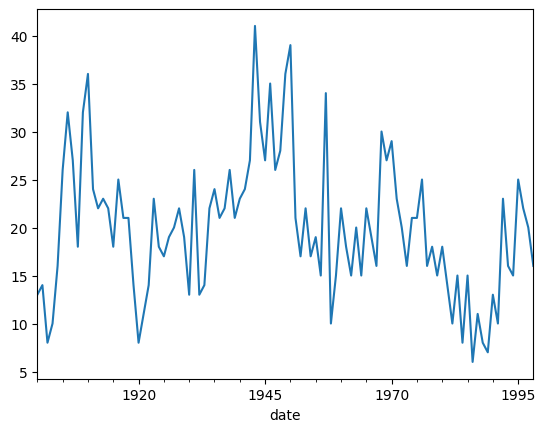

In [32]:
model = ARIMA(earthquake_df.asfreq('YS-JAN'), order=(1,0,1))
results = model.fit()

# calculate mean absolute error from residuals
mae = np.mean(np.abs(results.resid))

# print mean absolute error
print(f"Mean Absolute Error is {mae}")

# print model result summary
print(results.summary())

# make plot of time series for comparison
earthquake_df.plot()
plt.show()

#### Plot diagnosis
Diagnosis plots show good fitting 
* standardized residual for error is centered at zero
* histogram shows a curve close to normal distribution
* Q-Q plot is aligned except at the high value edge
* correlogram shows no significant correlation for lag > 0

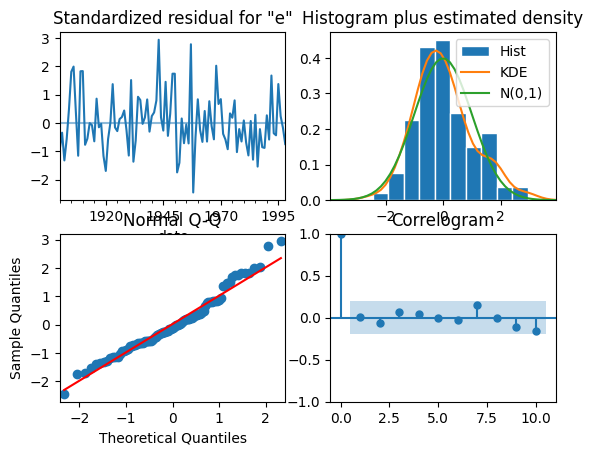

In [33]:
results.plot_diagnostics()
plt.show()

### Box-Jenkins method
Defines ARIMA workflow from raw data to production model
* identification
  + is the time series stationary?
  + what differencing will make it stationary?
  + what transformation will make it stationary?
  + what values of p and q are most promising?
* identification tools
  + plot the time series by df.plot()
  + use augmented Dicky-Fuller test by adfuller()
  + use transforms and/or differencing by df.diff(), np.log(), np.sqrt()
  + plot ACF/PACF by plot_acf() and plot_pacf()
* estimation
  + use the data to train the model coefficients
  + done for us using model.fit()
  + choose between models using AIC and BIC by results.aic, results.bic
* model diagnostics
  + Are the residuals uncorrelated
  + Are residuals normally distributed
    + results.plot_diagnostics()
    + results.summary()
* Decision
  + is model OK?
* Repeat
  + we go through the process with more information
  + find a better model
* Production
  + ready to make forecasts by results.get_forecast()    

### Seasonal ARIMA (SARIMA)
* using seasonal_decompose
  + decompose data to trend, seasonal and residual components
  + `from statsmodels.tsa.seasonal import seasonal_decompose`
  + we still need to specify the period
  + from data plot, we see there is a one year (12 months) repeat pattern. we can confirm by plot_acf()
  + to further confirm, subtract a rolling mean with window > 12 (e.g. 15) from the original data, and plot_acf()
    + the resulting acf showed a faked pattern of 6 lags, which is the incremental and decremental parts of the entire 12 period
  + decomposed composition consists of trend, seasonal and residual components and we can plot the decomposed compositions
    + when we set period=6, a clear period pattern showed in trend plot, which tells us that we are using the wrong period
* fit SARIMA model
  + SARIMA consists of two parts: non-seasonal and seasonal as expressed as SARIMA(p,d,q)(P,D,Q)period, for example, SARIMA(1,0,0)(1,1,0)7
    ```Python
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    # crate a SARIMA model
    model = SARIMAX(df, order=(1,0,0), seasonal_order=(1,1,0,7))

    # fit model
    results = model.fit()

    # print results summary
    print(results.summary())
    ```
* how SARIMA works
  + we can manually process the SARIMA workflow by differencing non-seasonal and seasonal lags.
    + this corresponds to differencing of non-seasonal(d) and seasonal(D) in SARIMA 
    ```Python
    df_diff = df.diff().diff(12).dropna()
    plot_acf(df_diff, lags=11, zero=False)
    ```
  + check by acf and pacf for remaining autocorrelations
    + plot_acf(lags=11) and plot_pacf(lags=11) of df_diff to see any autocorrelation AR and MA for non-seasonal part to define p and q
    + plot_acf(lags=\[12, 24, 36, 48, 60\]) and plot_pacf(lags=\[12, 24, 36, 48, 60\]) for the first 5 period to check and AR and MA for seasonal P and Q
    + non-seasonal has a weak lag 1, we can assume p = 0, and q = 0 with d=1
    + seasonal has a strong lag 1 on ACF and tail off pattern on PACF as MA(1), so P = 0, Q = 1, D=1
    + we use SARIMIAX(0, 1, 0)(0, 1, 1)12 model 

In [34]:
milk_path = data_path / "milk_production.csv"
milk_production = pd.read_csv(milk_path, index_col='date', parse_dates=['date'])
milk_production = milk_production.asfreq("MS")

#### Data explore to find seasonality

In [35]:
milk_production.head()

,pounds_per_cow
date,
1962-01-01,589.0
1962-02-01,561.0
1962-03-01,640.0
1962-04-01,656.0
1962-05-01,727.0


<Axes: xlabel='date'>

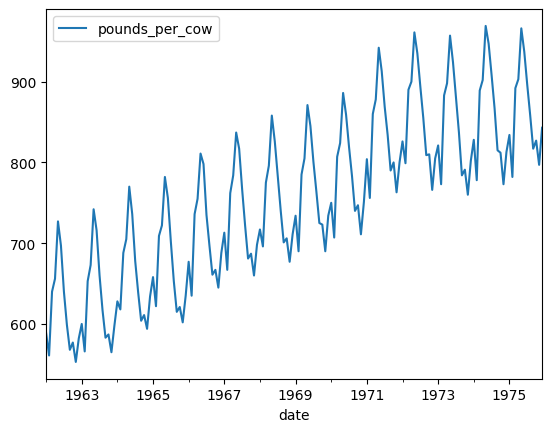

In [36]:
milk_production.plot()

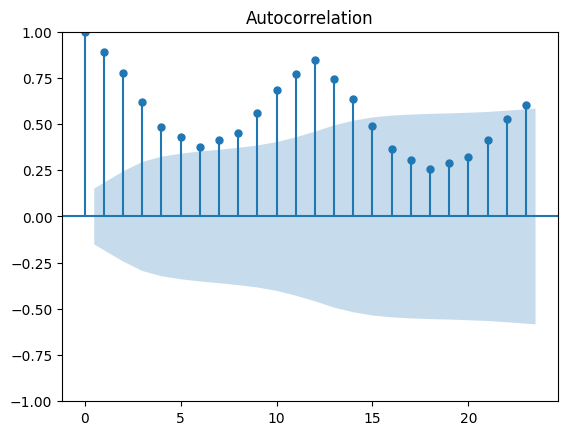

In [37]:
plot_acf(milk_production);

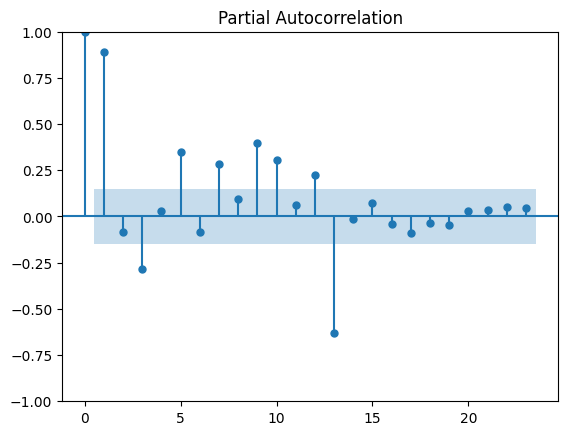

In [38]:
plot_pacf(milk_production);

#### subtract a long rolling mean and plot_acf()

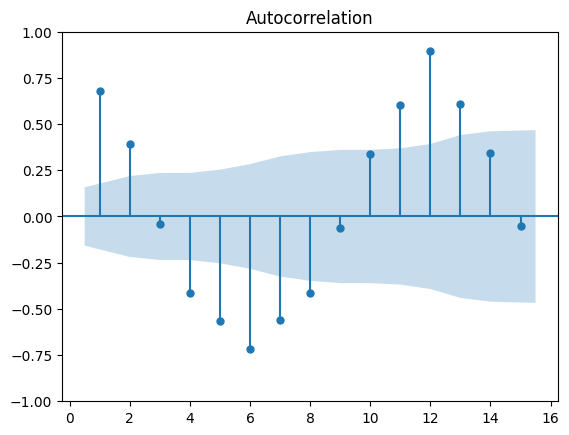

In [39]:
milk_production_sub = milk_production.sub(milk_production.rolling(15).mean()).dropna()
plot_acf(milk_production_sub, zero=False, lags=15);

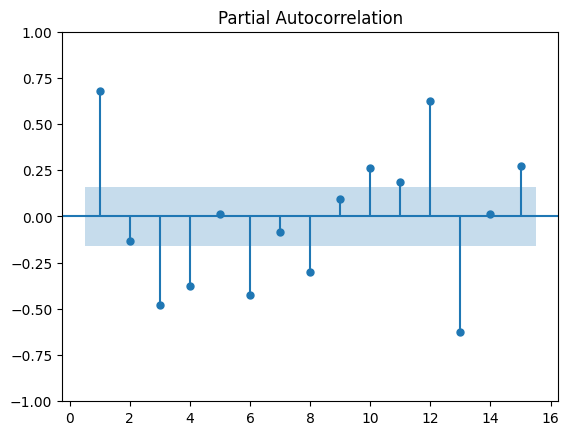

In [40]:
plot_pacf(milk_production_sub, zero=False, lags=15);

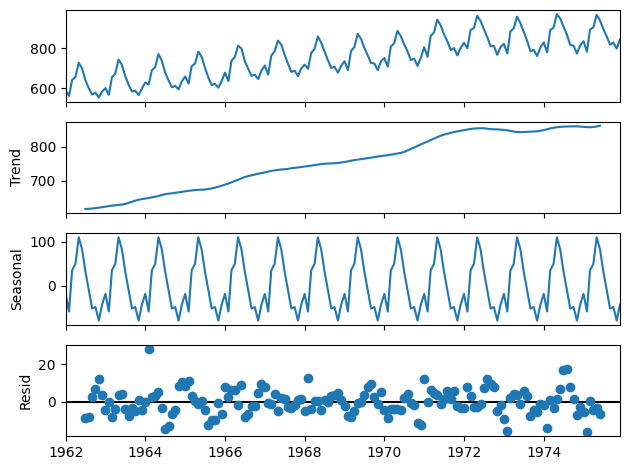

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

# perform additive decomposition
decomp = seasonal_decompose(milk_production, period=12)

# plot decomp
decomp.plot();

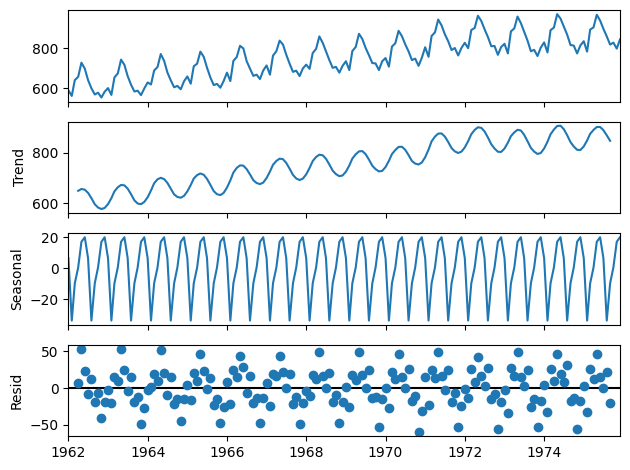

In [42]:
# perform additive decomposition
decomp = seasonal_decompose(milk_production, period=6)

# plot decomp
decomp.plot();

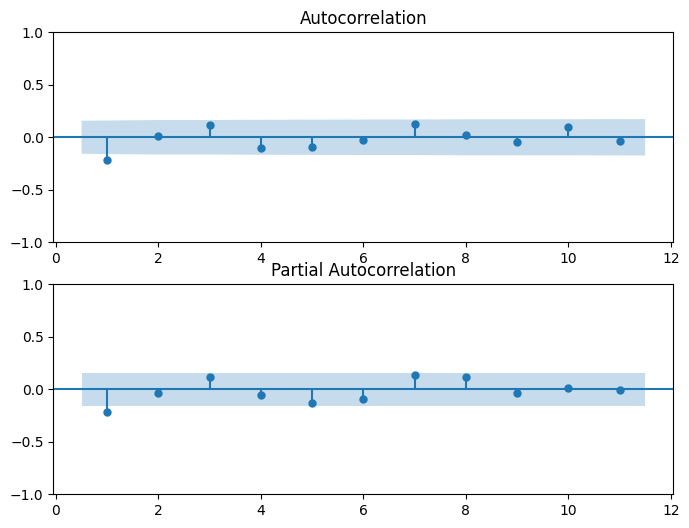

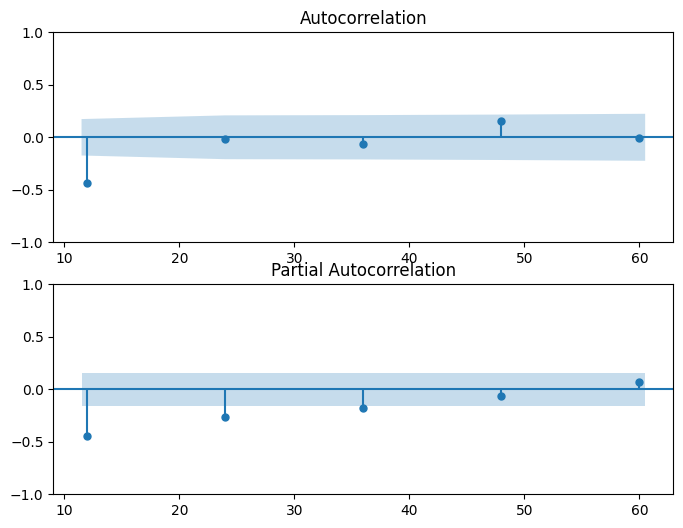

In [43]:
milk_prod_diff = milk_production.diff().diff(12).dropna()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,6))

# check non-seasonal AR and MA
plot_acf(milk_prod_diff, zero=False, lags=11, ax=ax1)
plot_pacf(milk_prod_diff, zero=False, lags=11, ax=ax2)
plt.show()

# check seasonal AR and MA
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(8,6))
seasonal_lags = [12, 24, 36, 48, 60]
plot_acf(milk_prod_diff, zero=False, lags=seasonal_lags, ax=ax3)
plot_pacf(milk_prod_diff, zero=False, lags=seasonal_lags, ax=ax4)
plt.show()


### Use SARIMA for data with seasonal components
* use SARIMA to model milk_production data, which has a 12 month seasonal component
* plot diagnosis
* perform one step prediction
* perform dynamic prediction
* perform forcasting for future dates  

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

# crate a SARIMA model
sarima_model = SARIMAX(milk_production, order=(0,1,0), seasonal_order=(0,1,1,12))
sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                       pounds_per_cow   No. Observations:                  168
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -534.140
Date:                              Thu, 05 Mar 2026   AIC                           1072.280
Time:                                      19:56:57   BIC                           1078.367
Sample:                                  01-01-1962   HQIC                          1074.752
                                       - 12-01-1975                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12      -0.6110      0.066     -9.285      0.000      -0.740      -0.482
sigma2        55.59

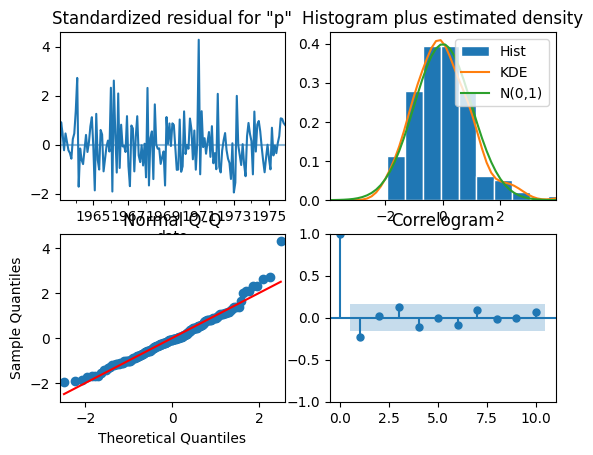

In [45]:
sarima_result.plot_diagnostics();

In [46]:
one_step_sarima_pred = sarima_result.get_prediction(start=-25)
mean_forecast = one_step_sarima_pred.predicted_mean
confidence_intervals = one_step_sarima_pred.conf_int()

date
1973-12-01    798.743095
1974-01-01    826.901607
1974-02-01    787.051632
1974-03-01    878.919950
1974-04-01    904.101881
1974-05-01    962.893334
1974-06-01    939.786766
1974-07-01    903.904880
1974-08-01    867.671050
1974-09-01    819.872913
1974-10-01    820.409520
1974-11-01    776.960899
1974-12-01    813.010105
1975-01-01    838.328907
1975-02-01    789.530384
1975-03-01    886.841271
1975-04-01    906.284211
1975-05-01    966.268937
1975-06-01    939.592844
1975-07-01    895.497956
1975-08-01    855.409999
1975-09-01    808.977262
1975-10-01    819.138065
1975-11-01    790.420038
1975-12-01    837.006174
Freq: MS, Name: predicted_mean, dtype: float64


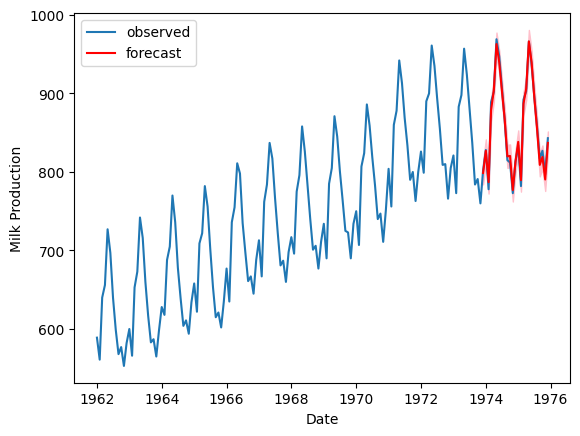

In [47]:
lower_limits = confidence_intervals.loc[:, 'lower pounds_per_cow']
upper_limits = confidence_intervals.loc[:, 'upper pounds_per_cow']

print(mean_forecast)

plt.plot(milk_production.index, milk_production, label='observed')
plt.plot(mean_forecast.index, mean_forecast, color='r', label='forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color='pink')

plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

date
1973-12-01    798.743095
1974-01-01    823.644702
1974-02-01    782.696334
1974-03-01    883.616283
1974-04-01    898.718164
1974-05-01    959.611498
1974-06-01    930.398264
1974-07-01    887.303144
1974-08-01    846.974194
1974-09-01    799.847107
1974-10-01    805.256627
1974-11-01    770.217526
1974-12-01    808.960621
1975-01-01    833.862228
1975-02-01    792.913860
1975-03-01    893.833809
1975-04-01    908.935690
1975-05-01    969.829024
1975-06-01    940.615790
1975-07-01    897.520670
1975-08-01    857.191720
1975-09-01    810.064633
1975-10-01    815.474153
1975-11-01    780.435052
1975-12-01    819.178147
Freq: MS, Name: predicted_mean, dtype: float64


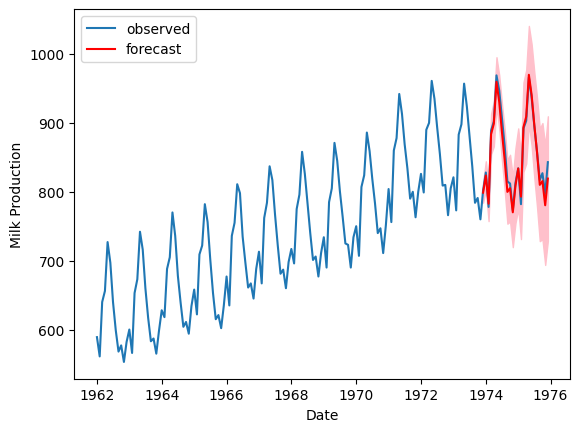

In [48]:
dynamic_sarima_pred = sarima_result.get_prediction(start=-25, dynamic=True)
mean_forecast = dynamic_sarima_pred.predicted_mean
confidence_intervals = dynamic_sarima_pred.conf_int()

lower_limits = confidence_intervals.loc[:, 'lower pounds_per_cow']
upper_limits = confidence_intervals.loc[:, 'upper pounds_per_cow']

print(mean_forecast)

plt.plot(milk_production.index, milk_production, label='observed')
plt.plot(mean_forecast.index, mean_forecast, color='r', label='forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color='pink')

plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

1976-01-01     866.644884
1976-02-01     819.245826
1976-03-01     926.093927
1976-04-01     939.100526
1976-05-01    1002.264842
1976-06-01     974.849028
1976-07-01     933.542287
1976-08-01     893.959839
1976-09-01     848.058076
1976-10-01     853.254562
1976-11-01     819.234312
1976-12-01     861.572182
1977-01-01     885.217066
1977-02-01     837.818008
1977-03-01     944.666109
1977-04-01     957.672708
1977-05-01    1020.837025
1977-06-01     993.421210
1977-07-01     952.114469
1977-08-01     912.532021
1977-09-01     866.630259
1977-10-01     871.826744
1977-11-01     837.806495
1977-12-01     880.144364
1978-01-01     903.789249
Freq: MS, Name: predicted_mean, dtype: float64


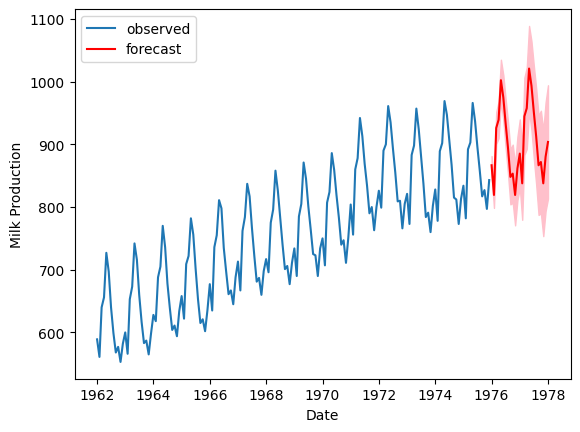

In [49]:
sarima_forecast = sarima_result.get_forecast(steps=25)
mean_forecast = sarima_forecast.predicted_mean
confidence_intervals = sarima_forecast.conf_int()

lower_limits = confidence_intervals.loc[:, 'lower pounds_per_cow']
upper_limits = confidence_intervals.loc[:, 'upper pounds_per_cow']

print(mean_forecast)

plt.plot(milk_production.index, milk_production, label='observed')
plt.plot(mean_forecast.index, mean_forecast, color='r', label='forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color='pink')

plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

In [50]:
import pmdarima as pm
import joblib
pm_model = pm.auto_arima(milk_production, seasonal=True,
                         m=12, d=1, D=1, start_p=0, start_q=0, max_p=1, max_q=1,
                         start_P=0, start_Q=0, max_P=1, max_Q=1,
                         trace=True, error_action='ignore',
                         suppress_warnings=True)
print(pm_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1119.969, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1081.584, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1066.296, Time=0.30 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1114.995, Time=0.07 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1068.030, Time=0.40 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1082.123, Time=0.16 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1072.280, Time=0.16 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1068.064, Time=0.38 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1066.207, Time=0.25 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1114.845, Time=0.06 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1067.913, Time=0.35 sec
 ARIMA(1,1,0)(0,1,1)[12] intercept   : AIC=1068.200, Time=0.48 sec

Best model:  ARIMA(1,1,0)(0,1,1)[12]          
Total fit time: 2.808 seconds
                                      SARIMAX Results                      

In [51]:
pm_model

,order,"(1, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [52]:
model_path = "milk_production.pkl"
joblib.dump(pm_model, model_path)

['milk_production.pkl']

In [53]:
loaded_model = joblib.load(model_path)
loaded_model.update(milk_production)

,order,"(1, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


### Box-Jenkins for SARIMA
* identification
  +  Multiplicative vs. additive seasonality
  * additive seasonality has constant variance vs time
  * multiplicative seasonality has incremental variance vs time, usually requiring log transformation
  * co2 data is additive, we don't need extra data transform
* identification tools
  + plot the time series by df.plot()
  + use augmented Dicky-Fuller test by adfuller()
  + use transforms and/or differencing by df.diff(), np.log(), np.sqrt()
  + plot ACF/PACF by plot_acf() and plot_pacf()
* estimation
  + use the data to train the model coefficients
  + done for us using model.fit()
  + choose between models using AIC and BIC by results.aic, results.bic
* model diagnostics
  + results.plot_diagnostics() show all good (centered mean, residual normal dist and good Q-Q plot and no autocorrelations
  + results.summary() shows no autocorrelation and residual has normal distribution
* Decision
  + is model OK?
* Repeat
  + we go through the process with more information
  + find a better model
* Production
  + ready to make forecasts by results.get_forecast()

In [54]:
co2_path = data_path / "co2.csv"
co2_df = pd.read_csv(co2_path, index_col='date', parse_dates=['date'])
co2_df = co2_df.asfreq("MS")

<Axes: xlabel='date'>

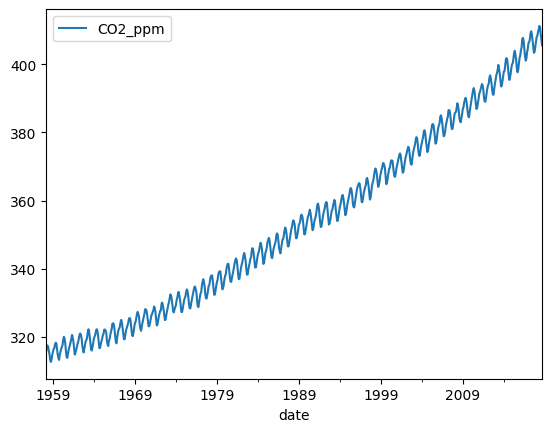

In [55]:
co2_df.plot()

In [56]:
co2_df.head()

,CO2_ppm
date,
1958-03-01,315.71
1958-04-01,317.45
1958-05-01,317.50
1958-06-01,317.10
1958-07-01,315.86


#### Identification
* use diff() to remove long term trend
* plot acf and pacf to show seasonality with 12 lags pattern
* plot acf and pacf of seasonality remove by further diff with 12 shift to show seasonality lags pattern after subtraction of seasonality
* decide order and seasonal_order  

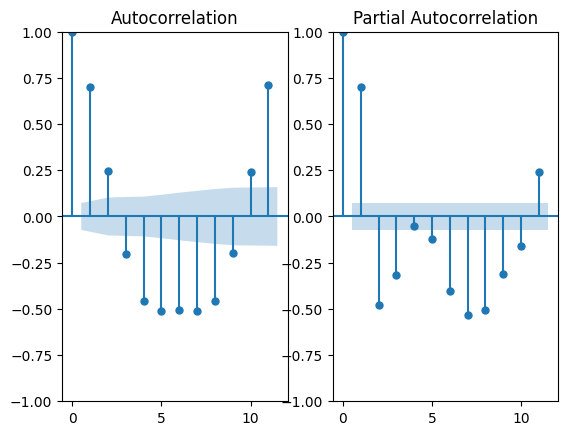

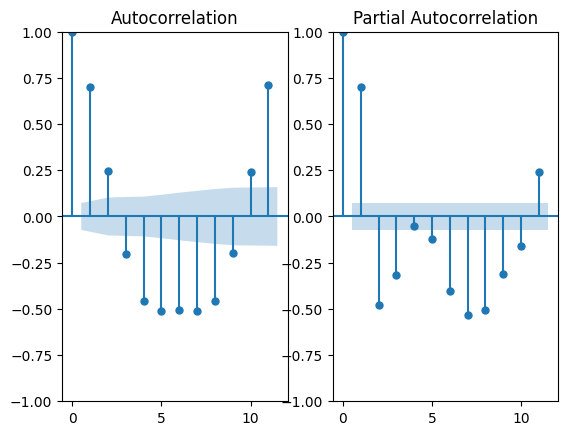

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2)
plot_acf(co2_df.diff().dropna(), lags=11, ax=ax1)
plot_pacf(co2_df.diff().dropna(), lags=11, ax=ax2)

#### seasonal lags
* after diff(), we plot acf and pacf, and find apparent lags 6 and 12. we will try the long 12 lags
* we will use co2_df.diff().diff(12).dropna() and plot acf and pacf for the first 5 seasonal cycles at 12, 24, 36, 48 and 60 lags
* acf and pacf showed MA(1) seasonal lag
* adfuller test showed very small p-value, so it is stationary after non-seasonal and seasonal differencing 

In [60]:
co2_diff = co2_df.diff().diff(12).dropna()
adfuller(co2_diff)

(-10.871271019716369,
 1.366543075329487e-19,
 12,
 701,
 {'1%': -3.4397129207385357,
  '5%': -2.8656718422599923,
  '10%': -2.568970295481694},
 549.2608104908404)

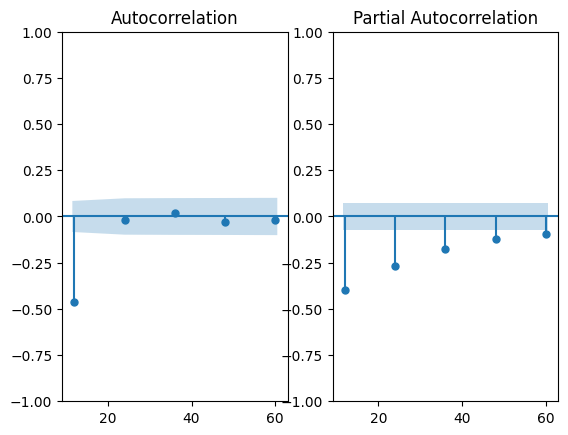

In [61]:
fig, (ax3, ax4) = plt.subplots(1, 2)
seasonal_lags = [12, 24, 36, 48, 60]
plot_acf(co2_diff, lags=seasonal_lags, ax=ax3);
plot_pacf(co2_diff, lags=seasonal_lags,ax=ax4);

#### Non-seasonal lags
* plot acf and pacf of lags = 11
* both acf and pacf cut off at 1 lag, so it is ARMA(1, 1)

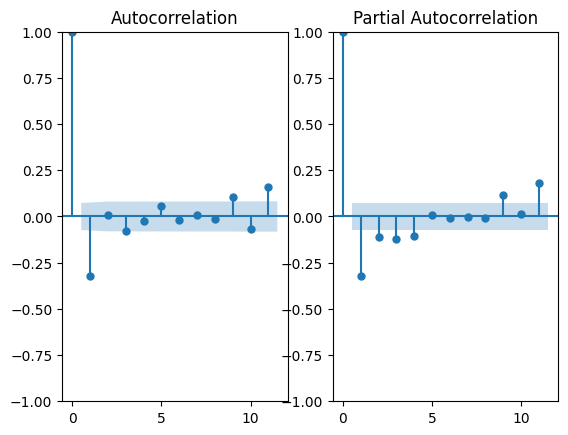

In [62]:
fig, (ax5, ax6) = plt.subplots(1, 2)

plot_acf(co2_diff, lags=11, ax=ax5);
plot_pacf(co2_diff, lags=11,ax=ax6);

#### Combine non-seasonal and seasonal patters to SARIMA
* non-seasonal: p=1, q=1, d=1
* seasonal: P=1, Q=1, D=1, m=12
* Prob(Q) shows no dependent autocorrelation
* Prob(JB) shows residuals are in normal distribution
* diagnosis plots show
  + zero centered residuals
  + residuals close to normal distribution
  + Q-Q plot aligned except several points at right edge, indicating residual normal distribution
  + correlogram shows no autocorrelation

In [63]:
co2_model = SARIMAX(co2_df, order=(1,1,1), seasonal_order=(0,1,1,12))
results = co2_model.fit()
print(results.summary())                    

                                     SARIMAX Results                                      
Dep. Variable:                            CO2_ppm   No. Observations:                  727
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -183.113
Date:                            Thu, 05 Mar 2026   AIC                            374.226
Time:                                    19:58:02   BIC                            392.510
Sample:                                03-01-1958   HQIC                           381.287
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1960      0.081      2.409      0.016       0.037       0.355
ma.L1         -0.5609      0.070   

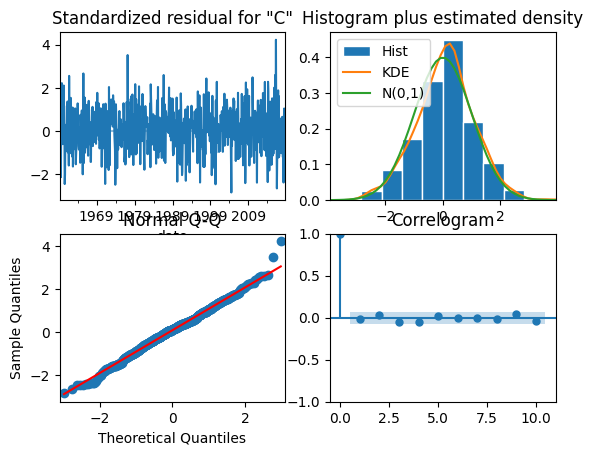

In [64]:
results.plot_diagnostics();

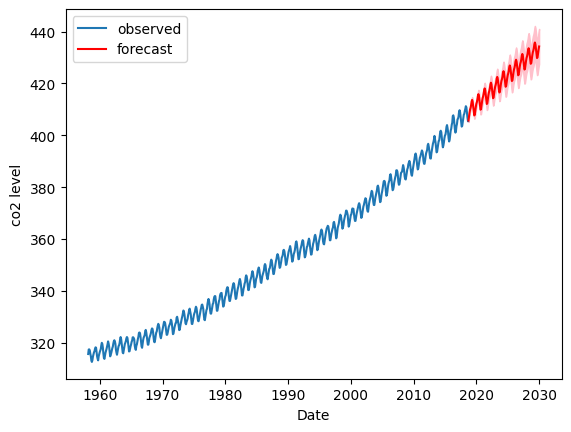

In [65]:
forecast_object = results.get_forecast(steps=136)
mean_forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

dates = mean_forecast.index

plt.plot(co2_df.index, co2_df, label='observed')
plt.plot(dates, mean_forecast, color='r', label='forecast')
plt.fill_between(dates, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink')

plt.xlabel('Date')
plt.ylabel('co2 level')
plt.legend()
plt.show()

In [66]:
# print last predicted mean
print(mean_forecast.iloc[-1])

# print last confidence interval
print(conf_int.iloc[-1])

434.2604725061958
lower CO2_ppm    427.484739
upper CO2_ppm    441.036206
Name: 2030-01-01 00:00:00, dtype: float64
